## EDA первых 10-ти признаков **campaigns.csv**

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('campaigns.csv')
df

,id,campaign_type,channel,topic,started_at,finished_at,total_count,ab_test,warmup_mode,hour_limit,subject_length,subject_with_personalization,subject_with_deadline,subject_with_emoji,subject_with_bonuses,subject_with_discount,subject_with_saleout,is_test,position
0,63,bulk,mobile_push,sale out,2021-04-30 07:22:36.615023,2021-04-30 07:23:41,48211.0,NaN,False,NaN,146.0,False,False,True,False,False,False,NaN,NaN
1,64,bulk,mobile_push,sale out,2021-04-30 09:02:50.817227,2021-04-30 09:04:08,1037337.0,NaN,False,NaN,97.0,False,False,True,False,False,False,NaN,NaN
2,78,bulk,mobile_push,sale out,2021-05-06 07:14:10.533318,2021-05-06 07:15:17,70080.0,NaN,False,NaN,146.0,False,False,True,False,False,False,NaN,NaN
3,79,bulk,mobile_push,sale out,2021-05-06 09:03:56.486750,2021-05-06 09:42:15,921838.0,NaN,False,NaN,97.0,False,False,True,False,False,False,NaN,NaN
4,89,bulk,mobile_push,NaN,2021-05-07 11:54:06.168664,2021-05-07 11:54:38,45503.0,NaN,False,NaN,109.0,False,True,True,False,False,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1902,179,transactional,email,profile updated,NaN,NaN,NaN,NaN,NaN,NaN,134.0,False,False,False,False,False,False,NaN,NaN
1903,35,transactional,email,order reminder,NaN,NaN,NaN,NaN,NaN,NaN,88.0,False,False,False,False,False,False,NaN,NaN
1904,57,transactional,email,order reminder,NaN,NaN,NaN,NaN,NaN,NaN,88.0,False,False,False,False,False,False,NaN,NaN
1905,56,transactional,email,order reminder,NaN,NaN,NaN,NaN,NaN,NaN,88.0,False,False,False,False,False,False,NaN,NaN


In [ ]:
for col in df.columns:
    print(f'\n{col}:')
    print(df[col].unique())


id:
[ 63  64  78 ...  57  56 237]

campaign_type:
['bulk' 'trigger' 'transactional']

channel:
['mobile_push' 'email' 'multichannel' 'sms']

topic:
['sale out' nan 'event' 'offer after purchase' 'happy birthday'
 'leave review' 'welcome campaign' 'abandoned cart' 'abandoned category'
 'abandoned view' 'added to wish list' 'abandoned search' 'subscribed'
 'removed from wish list' 'double opt in' 'user added to segment'
 'recent purchase' 'price drop' 'back in stock' 'order shipped'
 'order reminder' 'welcome letter' 'order ready for pickup'
 'order created' 'bonuses expired' 'order cancelled'
 'order pickup still pending' 'profile updated' 'wish list status']

started_at:
['2021-04-30 07:22:36.615023' '2021-04-30 09:02:50.817227'
 '2021-05-06 07:14:10.533318' ... '2023-04-21 09:00:14.149364'
 '2023-04-21 14:49:31.835109' '2023-04-21 15:30:14.136724']

finished_at:
['2021-04-30 07:23:41' '2021-04-30 09:04:08' '2021-05-06 07:15:17' ...
 '2023-04-21 09:01:10' '2023-04-21 14:49:54' '2023-0

## **Значения:**

**campaign_type** - тип кампании
*   bulk - массовая
*   trigger- автоматическая
*   transactional - транзакция (связана с действиями пользователя)

**channel** - Канал коммуникации


**topic** - Значение кампании (тема)

**started_at, finished_at** - Дата и время начала/завершения массовой кампании

**total_count** - Общее количество получателей в массовой кампании

**ab_test** - Массовая кампания в тестовом режиме A/B

**warmup_mode** - Массовая кампания в режиме разогрева

**hour_limit** - Ограничение на час для массовой кампании в режиме разогрева

**subject_length** - Длина темы сообщения














Для начала рассмотрим кол-во пропусков в каждом столбце

In [4]:
df.isna().sum()

,0
id,0
campaign_type,0
channel,0
topic,30
started_at,83
finished_at,99
total_count,83
ab_test,1895
warmup_mode,77
hour_limit,1876


In [5]:
df.shape

(1907, 19)

Рассмтариваю я признаки до subject_length(включительно)

В нашем датасете всего 1907 строк. Видим, что у 2-х признаков почти все значения - пропуски:


*   ab_test - 1895
*   hour_limit - 1876

Соответственно эти признаки не несут в себе пости никакой информации, рассматривать их в работе не стоит.

## **Вывод:** ab_test и hour_limit -неиформативные признаки

Теперь рассмотрим дубликаты по id (по идентификатору кампании)

In [ ]:
df['id'].duplicated().sum()

np.int64(7)

In [ ]:
df['id'].value_counts()[df['id'].value_counts() > 1]

,count
id,
381,2
374,2
373,2
64,2
372,2
368,2
366,2


Видим, что 7 идентификаторов встречаются дважды, рассмотрим их подробнее

In [ ]:
df[df['id'].duplicated(keep=False)]

,id,campaign_type,channel,topic,started_at,finished_at,total_count,ab_test,warmup_mode,hour_limit,subject_length,subject_with_personalization,subject_with_deadline,subject_with_emoji,subject_with_bonuses,subject_with_discount,subject_with_saleout,is_test,position
1,64,bulk,mobile_push,sale out,2021-04-30 09:02:50.817227,2021-04-30 09:04:08,1037337.0,NaN,False,NaN,97.0,False,False,True,False,False,False,NaN,NaN
34,366,bulk,email,sale out,2021-06-10 08:28:34.471796,2021-06-10 10:19:05,160689.0,NaN,False,NaN,85.0,False,False,True,False,False,False,NaN,NaN
35,368,bulk,mobile_push,sale out,2021-06-11 10:00:11.717483,2021-06-11 10:00:22,16027.0,NaN,False,NaN,117.0,False,False,True,False,False,False,NaN,NaN
36,372,bulk,mobile_push,sale out,2021-06-10 13:00:10.520899,2021-06-10 13:00:21,24425.0,NaN,False,NaN,119.0,False,False,True,False,True,False,NaN,NaN
37,373,bulk,mobile_push,sale out,2021-06-11 14:00:11.427774,2021-06-14 06:00:54,2532.0,NaN,False,NaN,111.0,False,False,True,False,False,False,NaN,NaN
38,374,bulk,email,sale out,2021-06-09 14:15:49.003420,2021-06-09 14:15:59,3.0,NaN,False,NaN,85.0,False,False,True,False,False,False,NaN,NaN
41,381,bulk,email,sale out,2021-06-10 08:10:36.944182,2021-06-10 08:10:48,3.0,NaN,False,NaN,85.0,False,False,True,False,False,False,NaN,NaN
1860,366,transactional,mobile_push,order reminder,NaN,NaN,NaN,NaN,NaN,NaN,125.0,False,False,False,False,False,False,NaN,NaN
1867,64,transactional,email,order ready for pickup,NaN,NaN,NaN,NaN,NaN,NaN,139.0,False,False,False,False,False,False,NaN,NaN
1881,368,transactional,mobile_push,order created,NaN,NaN,NaN,NaN,NaN,NaN,111.0,False,False,False,False,False,False,NaN,NaN


Видим, что каждый дубликат по id отличается по campaign_type

Т.е. у каждой пары одинаковых идентификаторов разный тип кампании.

В некоторых контекстах кампания может одновременно иметь типы bulk и transactional, так что ошибки в данных нет.

### Рассмотрим категориальные признаки:

In [8]:
cat_cols = [
    'campaign_type',
    'channel',
    'topic',
]

In [9]:
for col in cat_cols:
    print(f'\n=== {col} ===')
    print(df[col].value_counts(dropna=False))


=== campaign_type ===
campaign_type
bulk             1830
transactional      50
trigger            27
Name: count, dtype: int64

=== channel ===
channel
mobile_push     1396
email            483
multichannel      27
sms                1
Name: count, dtype: int64

=== topic ===
topic
sale out                      779
happy birthday                332
offer after purchase          316
leave review                  287
event                          63
NaN                            30
welcome campaign               27
order ready for pickup         10
order shipped                  10
order created                  10
order reminder                  9
abandoned cart                  6
order pickup still pending      4
abandoned view                  3
abandoned search                2
added to wish list              2
abandoned category              2
subscribed                      2
order cancelled                 2
price drop                      2
removed from wish list          1
b

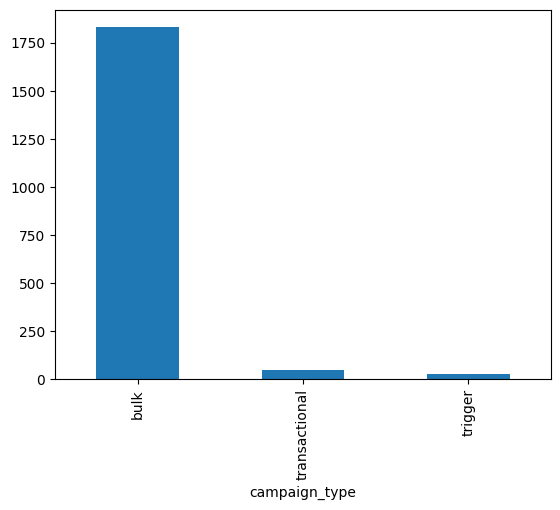

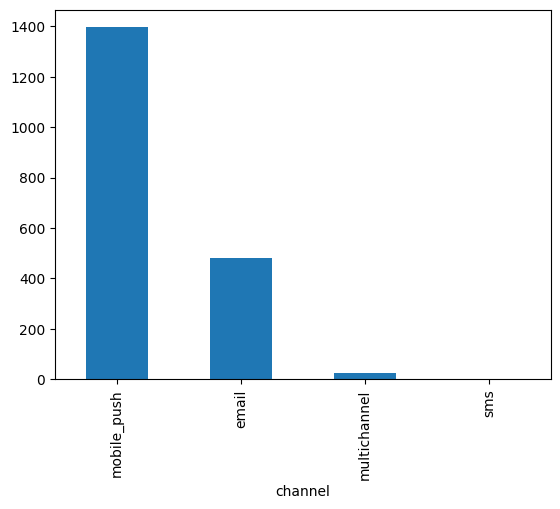

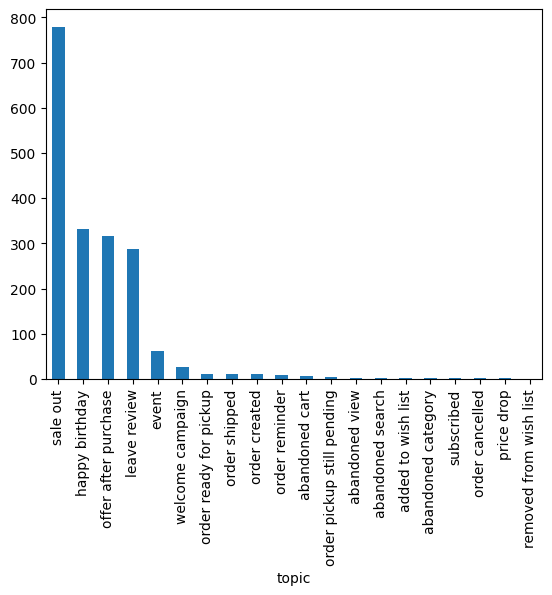

In [ ]:
df['campaign_type'].value_counts().plot.bar()
plt.show()

df['channel'].value_counts().plot.bar()
plt.show()

df['topic'].value_counts().head(20).plot.bar()
plt.show()

## **campaign_type**

В нашем датасете преобладает bulk (т.е. массовая). Распределение сильно неравномерное

### **channel**

Говоря о каналах коммуникации, видим, что большая часть относится к mobile_push и email. sms и multichannel берут на себя очень маленькую часть

### **topic**

Распределение значения кампании (тема) так же сильно неравномерное. Очень много тем, которые встречаются по 1-10 раз. С другой стороны, тема sale out встречается аж 779 раз.


### Рассмотрим числовые признаки:

In [10]:
num_cols = [
    'total_count',
    'subject_length'
]
df[num_cols].describe()

,total_count,subject_length
count,1.824000e+03,1880.000000
mean,3.741295e+05,94.340426
std,8.198459e+05,28.482613
min,1.000000e+00,4.000000
25%,8.467500e+02,92.000000
50%,2.006500e+03,96.000000
75%,2.820332e+05,112.000000
max,5.371769e+06,185.000000


Для начала проверим на нормальность критерием Шапиро-Уилка:

In [11]:
stats.shapiro(df['total_count'].dropna())

ShapiroResult(statistic=np.float64(0.5251136581653486), pvalue=np.float64(7.708593064248773e-57))

In [13]:
stats.shapiro(df['subject_length'].dropna())

ShapiroResult(statistic=np.float64(0.7815101961616435), pvalue=np.float64(1.3386212327723765e-44))

pvalue в обоих случаях стремиться к нулю, что говорит нам о том, что распределение **сильно** не нормальное

### **total_count**

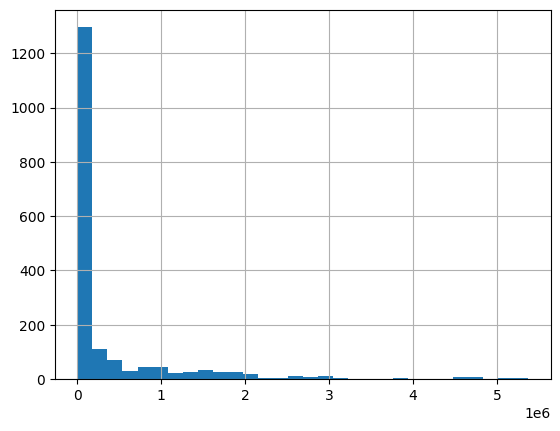

In [14]:
df['total_count'].dropna().hist(bins=30)
plt.show()

Видим, что большая часть кампаний имеют небольшое количество получателей, но так же есть и небольшое количество очень крупных кампаний, присутсвуют выбросы

In [15]:
df['total_count'].dropna().quantile([0.5, 0.9, 0.95, 0.99])

,total_count
0.50,2006.50
0.90,1360510.10
0.95,1964064.35
0.99,4506894.76


<Axes: >

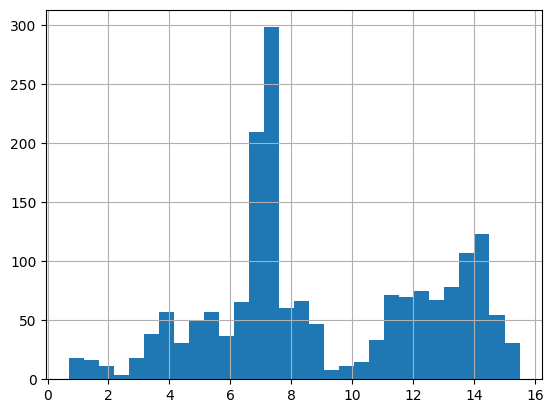

In [16]:
np.log1p(df['total_count']).dropna().hist(bins=30)#plt.show()

### **subject_length**

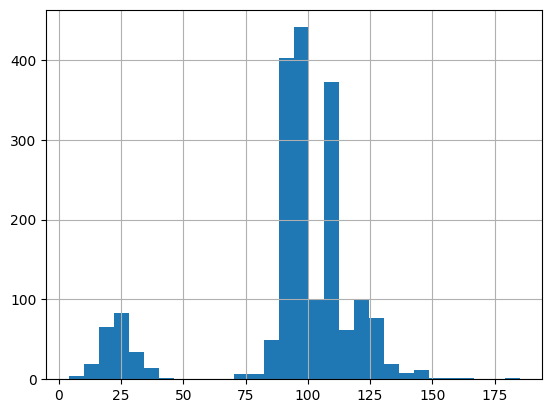

In [ ]:
df['subject_length'].dropna().hist(bins=30)
plt.show()

Тут ситуация интереснее. Видим 2 локальных пика (в 25 и в 100), но это обосновано тем, что в нашем датасете преобладают mobile_push и email.



In [ ]:
df.groupby('channel')['subject_length'].describe()

,count,mean,std,min,25%,50%,75%,max
channel,,,,,,,,
email,483.0,108.792961,16.100649,18.0,97.0,108.0,120.0,185.0
mobile_push,1396.0,89.402579,30.016169,4.0,92.0,96.0,112.0,164.0
multichannel,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sms,1.0,7.000000,NaN,7.0,7.0,7.0,7.0,7.0


### Рассмотрим временные признаки:

In [ ]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['finished_at'] = pd.to_datetime(df['finished_at'])